In [1]:
import numpy as np

from utils_io import load_data
from utils_noise import add_saltpepper_noise, add_gaussian_noise, add_block_occlusion
from utils_metrics import evaluate, relative_reconstruction_error
from utils_vis import compare_images
from alg_l2nmf import l2_nmf 
from alg_l1rrnmf import l1_rrnmf
from utils_pipeline import run_pipeline

In [2]:
# --- 1) dataset ---
DATA_ROOT = 'data/ORL'
IMAGE_SHAPE = (92, 112)   
REDUCE = 2        
SEED = 42

print('==> Load dataset ...')
V_hat, Y_hat = load_data(root=DATA_ROOT, reduce=REDUCE)   # clean matrix (pixels × samples)
V_hat = V_hat.astype(np.float64, copy=False)
print('V_hat.shape =', V_hat.shape, '  # pixels × samples')

==> Load dataset ...
V_hat.shape = (2576, 400)   # pixels × samples


==> Load dataset ...
V_hat.shape = (2576, 400)   # pixels × samples
==> Add noise ...


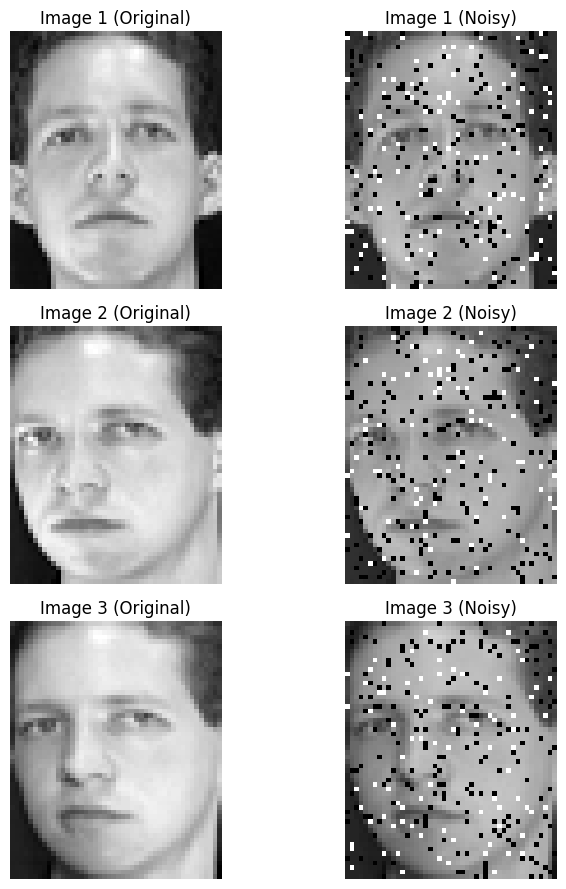

Using k = 40
==> Regular NMF ...
Iteration 100: Error H = 0.000057,  Error W = 0.000011
Iteration 200: Error H = 0.000023,  Error W = 0.000004
Iteration 300: Error H = 0.000012,  Error W = 0.000002
Converged at iteration 334
==> L1-RR NMF (explicit E) ...
Iteration 1: ΔU=9.895e-01 ΔV=2.037e+02 ΔE=1.205e-01
Iteration 100: ΔU=3.743e-03 ΔV=2.743e-03 ΔE=1.441e-02
Iteration 200: ΔU=6.217e-03 ΔV=1.626e-03 ΔE=1.732e-01
Iteration 300: ΔU=4.249e-03 ΔV=5.403e-04 ΔE=1.651e-01
Iteration 400: ΔU=4.191e-03 ΔV=4.539e-04 ΔE=1.584e-01
Iteration 500: ΔU=5.773e-04 ΔV=2.705e-05 ΔE=1.959e-02
Iteration 600: ΔU=5.199e-04 ΔV=2.953e-05 ΔE=1.956e-02
Iteration 700: ΔU=5.145e-04 ΔV=2.157e-05 ΔE=1.952e-02
Iteration 800: ΔU=5.193e-04 ΔV=2.561e-05 ΔE=1.948e-02
Iteration 900: ΔU=5.078e-04 ΔV=2.706e-05 ΔE=1.944e-02
Iteration 1000: ΔU=5.170e-04 ΔV=2.237e-05 ΔE=1.940e-02
Iteration 1100: ΔU=5.098e-04 ΔV=2.271e-05 ΔE=1.937e-02
Iteration 1200: ΔU=5.109e-04 ΔV=2.325e-05 ΔE=1.933e-02
Iteration 1300: ΔU=5.090e-04 ΔV=2.123e-05

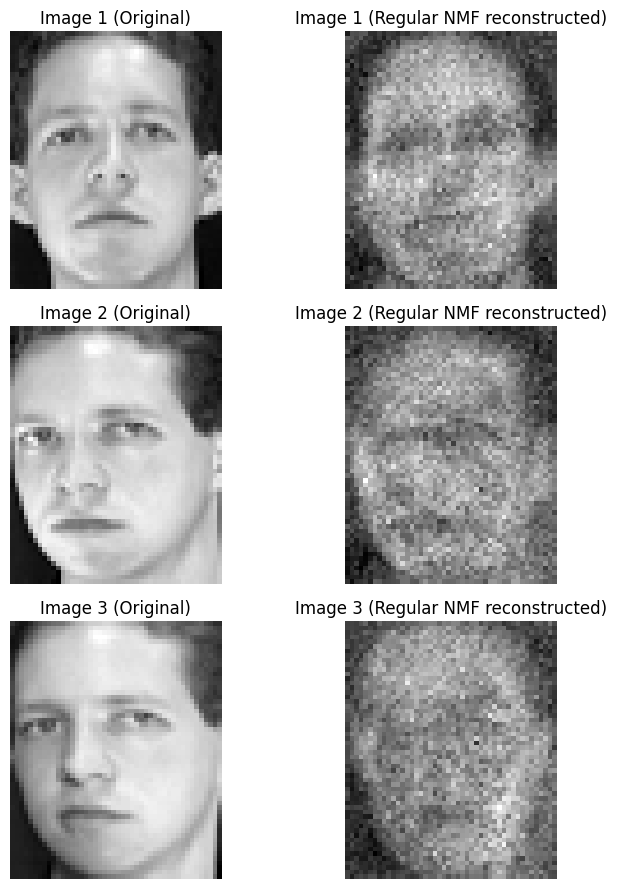

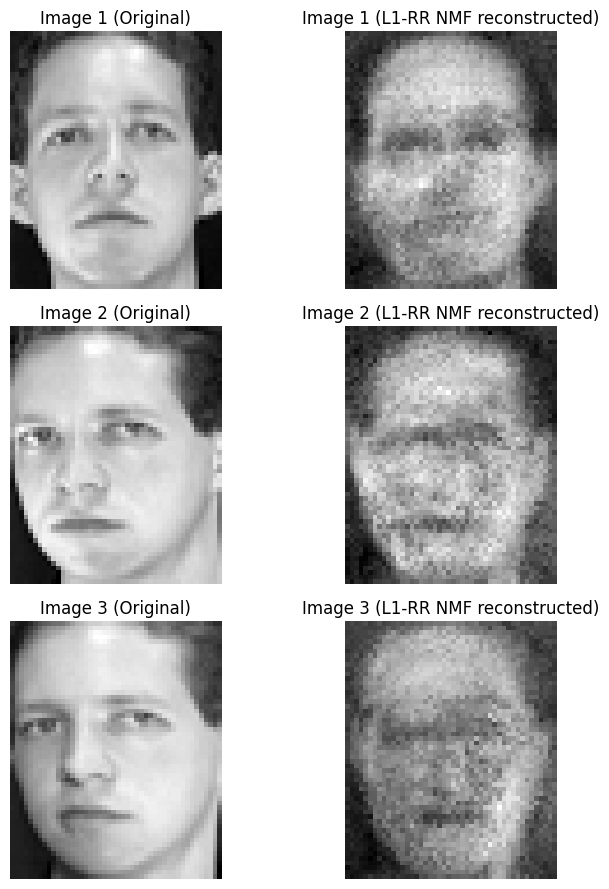

In [ ]:
# --- 1) dataset ---
DATA_ROOT = 'data/ORL'
IMAGE_SHAPE = (92, 112)   
REDUCE = 2        
SEED = 42

print('==> Load dataset ...')
V_hat, Y_hat = load_data(root=DATA_ROOT, reduce=REDUCE)   # clean matrix (pixels × samples)
V_hat = V_hat.astype(np.float64, copy=False)
print('V_hat.shape =', V_hat.shape, '  # pixels × samples')

# --- 2) make a noisy version ---
print('==> Add noise ...')
V_noise, noise_mask = add_saltpepper_noise(V_hat, p=0.10, r=0.30, random_state=SEED)
V_noise = V_noise.astype(np.float64, copy=False)

compare_images(V_hat, V_noise, image_shape=IMAGE_SHAPE, reduce=REDUCE,
               num_images=3, titles=("Original","Noisy"))

# --- 3) set rank ---
k = len(set(Y_hat))  
print('Using k =', k)

# --- 4) Regular NMF (multiplicative updates) ---
print('==> Regular NMF ...')
W_reg, H_reg = l2_nmf(V_noise, k=k, max_iter=2000, tol=1e-5,
                                verbose=True, random_state=SEED, init="nndsvd")

# --- 5) L1-regularized robust NMF with explicit E ---
print('==> L1-RR NMF (explicit E) ...')
U_rob, V_rob, E_rob = l1_rrnmf(X=V_noise, k=k, lam=0.02, max_iter=2000, tol=1e-5,
                               init="nndsvd", random_state=SEED, verbose=True, log_every=100)
# 
# --- 6) Evaluate both against clean V_hat ---
print('==> Evaluate metrics ...')
rre_reg, acc_reg, nmi_reg = evaluate(V_hat, W_reg, H_reg, Y_hat)
rre_rob, acc_rob, nmi_rob = evaluate(V_hat, U_rob, V_rob, Y_hat)

print(f"[Regular NMF]   RRE={rre_reg:.4f}  ACC={acc_reg:.4f}  NMI={nmi_reg:.4f}")
print(f"[L1-RR NMF(E)]  RRE={rre_rob:.4f}  ACC={acc_rob:.4f}  NMI={nmi_rob:.4f}")

# --- 7) visualize reconstructions ---
compare_images(V_hat, W_reg @ H_reg, image_shape=IMAGE_SHAPE, reduce=REDUCE,
               num_images=3, titles=("Original","Regular NMF reconstructed"))
compare_images(V_hat, U_rob @ V_rob, image_shape=IMAGE_SHAPE, reduce=REDUCE,
               num_images=3, titles=("Original","L1-RR NMF reconstructed"))

In [3]:
noise_specs = [
    {"name": "S&P p=0.2 r=0.1", "fn": add_saltpepper_noise, "kwargs": {"p": 0.2, "r": 0.1}},
    {"name": "S&P p=0.2 r=0.7", "fn": add_saltpepper_noise, "kwargs": {"p": 0.2, "r": 0.7}},
    {"name": "S&P p=0.4 r=0.1", "fn": add_saltpepper_noise, "kwargs": {"p": 0.4, "r": 0.1}},
]

algos = [
        {"name": "NMF-MUR(L2)", "fn": l2_nmf, "kwargs": {"init": "nndsvd"}},
        # {"name": "Robust-L1S",  "fn": l1_rrnmf, "kwargs": {"init": "nndsvd"}},
    ]


In [4]:
results = run_pipeline(V_hat, Y_hat, noise_specs, algos, k=40, repeats=5, random_state=SEED)

Repetition: 1, Algorithm=NMF-MUR(L2), Noise=S&P p=0.2 r=0.1
Iteration 100: ΔH = 0.000054,  ΔW = 0.000010
Iteration 200: ΔH = 0.000023,  ΔW = 0.000004
Iteration 300: ΔH = 0.000014,  ΔW = 0.000002
Iteration 400: ΔH = 0.000010,  ΔW = 0.000002
Iteration 500: ΔH = 0.000007,  ΔW = 0.000001
Iteration 600: ΔH = 0.000006,  ΔW = 0.000001
Iteration 700: ΔH = 0.000005,  ΔW = 0.000001
Iteration 800: ΔH = 0.000004,  ΔW = 0.000001
Iteration 900: ΔH = 0.000003,  ΔW = 0.000001
Iteration 1000: ΔH = 0.000003,  ΔW = 0.000000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Repetition: 2, Algorithm=NMF-MUR(L2), Noise=S&P p=0.2 r=0.1
Iteration 100: ΔH = 0.000057,  ΔW = 0.000011
Iteration 200: ΔH = 0.000024,  ΔW = 0.000004
Iteration 300: ΔH = 0.000013,  ΔW = 0.000002
Iteration 400: ΔH = 0.000009,  ΔW = 0.000002
Iteration 500: ΔH = 0.000007,  ΔW = 0.000001
Iteration 600: ΔH = 0.000006,  ΔW = 0.000001
Iteration 700: ΔH = 0.000005,  ΔW = 0.000001
Iteration 800: ΔH = 0.000004,  ΔW = 0.000001
Iteration 900: ΔH = 0.000003,  ΔW = 0.000001
Iteration 1000: ΔH = 0.000003,  ΔW = 0.000001
Repetition: 3, Algorithm=NMF-MUR(L2), Noise=S&P p=0.2 r=0.1


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Iteration 100: ΔH = 0.000057,  ΔW = 0.000011
Iteration 200: ΔH = 0.000024,  ΔW = 0.000004
Iteration 300: ΔH = 0.000013,  ΔW = 0.000002
Iteration 400: ΔH = 0.000009,  ΔW = 0.000002
Iteration 500: ΔH = 0.000006,  ΔW = 0.000001
Iteration 600: ΔH = 0.000004,  ΔW = 0.000001
Iteration 700: ΔH = 0.000003,  ΔW = 0.000001
Iteration 800: ΔH = 0.000003,  ΔW = 0.000001
Iteration 900: ΔH = 0.000002,  ΔW = 0.000000
Iteration 1000: ΔH = 0.000002,  ΔW = 0.000000


...

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Iteration 100: ΔH = 0.000047,  ΔW = 0.000009
Iteration 200: ΔH = 0.000017,  ΔW = 0.000003
Iteration 300: ΔH = 0.000009,  ΔW = 0.000002
Iteration 400: ΔH = 0.000005,  ΔW = 0.000001
Iteration 500: ΔH = 0.000004,  ΔW = 0.000001
Iteration 600: ΔH = 0.000003,  ΔW = 0.000001
Iteration 700: ΔH = 0.000002,  ΔW = 0.000000
Iteration 800: ΔH = 0.000002,  ΔW = 0.000000
Iteration 900: ΔH = 0.000001,  ΔW = 0.000000
Iteration 1000: ΔH = 0.000001,  ΔW = 0.000000
Repetition: 5, Algorithm=NMF-MUR(L2), Noise=S&P p=0.4 r=0.1


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Iteration 100: ΔH = 0.000048,  ΔW = 0.000009
Iteration 200: ΔH = 0.000018,  ΔW = 0.000003
Iteration 300: ΔH = 0.000010,  ΔW = 0.000002
Iteration 400: ΔH = 0.000006,  ΔW = 0.000001
Iteration 500: ΔH = 0.000004,  ΔW = 0.000001
Iteration 600: ΔH = 0.000003,  ΔW = 0.000001
Iteration 700: ΔH = 0.000002,  ΔW = 0.000000
Iteration 800: ΔH = 0.000002,  ΔW = 0.000000
Iteration 900: ΔH = 0.000002,  ΔW = 0.000000
Iteration 1000: ΔH = 0.000002,  ΔW = 0.000000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [6]:
import pandas as pd

df = pd.DataFrame(results)
df

,noise,algo,RRE_mean,RRE_std,ACC_mean,ACC_std,NMI_mean,NMI_std
0,S&P p=0.2 r=0.1,NMF-MUR(L2),0.278881,0.000771,0.597778,0.021473,0.748285,0.008669
1,S&P p=0.2 r=0.7,NMF-MUR(L2),0.282503,0.000828,0.530000,0.012095,0.693067,0.007784
2,S&P p=0.4 r=0.1,NMF-MUR(L2),0.411830,0.000506,0.356667,0.020382,0.542181,0.017008
